In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

import pandas as pd
import numpy as np
from scipy.stats import ks_2samp

In [40]:
# univariate statistics
max_steps = 100000
step_size = 1000

ts = [x * step_size for x in range(1, int(max_steps/step_size) + 1)]

In [41]:
df = pd.read_csv("./SC_Ensemble_Stats/chain_outputs_0_1000.csv")

for t in ts[1:]:
    df2 = pd.read_csv(f"./SC_Ensemble_Stats/chain_outputs_0_{t}.csv")
    df = pd.concat([df, df2], ignore_index=True)

In [42]:
con_blackpercs = []

for t in ts:
    tempvotes=np.loadtxt(f"./SC_Ensemble_Stats/BlackPercs_0_{t}.csv", delimiter=",")
    for s in range(step_size-1):
        con_blackpercs.append(tempvotes[s,:])

con_blackpercs = pd.DataFrame(con_blackpercs)

medianprops = dict(color='black')

c_con="tab:blue"

In [55]:
rep_df = con_blackpercs[df["DWins"] == 0]
c = "tab:red"

C:\Users\angel\AppData\Local\Temp\ipykernel_21460\3686511094.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  rep_df = con_blackpercs[df["DWins"] == 0]


Text(0.5, 1.0, 'SC Districts % Black, 0 D Seats')

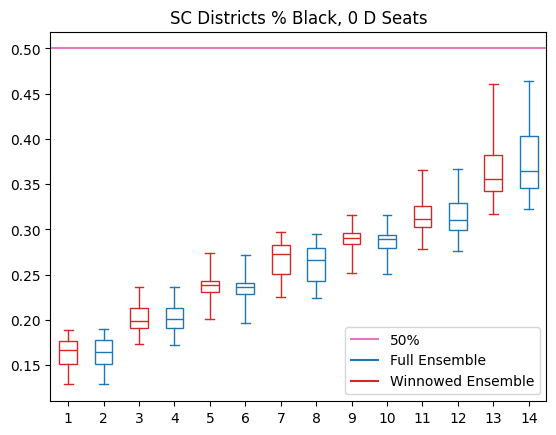

In [56]:
plt.boxplot(
    rep_df,
    positions=[1,3,5,7,9,11,13],
    whis=[1,99],
    showfliers=False,
    patch_artist=True,
    boxprops=dict(facecolor="None", color=c),
    capprops=dict(color=c),
    whiskerprops=dict(color=c),
    flierprops=dict(color=c,markeredgecolor=c),
    medianprops=dict(color=c)
)

plt.boxplot(
    con_blackpercs,
    positions=[2,4,6,8,10,12,14],
    whis=[1,99],
    showfliers=False,
    patch_artist=True,
    boxprops=dict(facecolor="None", color=c_con),
    capprops=dict(color=c_con),
    whiskerprops=dict(color=c_con),
    flierprops=dict(color=c_con,markeredgecolor=c_con),
    medianprops=dict(color=c_con)
)

"""plt.plot(,sorted([0.1828165961087225,
 0.18492617005629175,
 0.19797997475993911,
 0.25449946333226225,
 0.2663038733124516,
 0.2726958300124814,
 0.4819280068798886]),"*",color="k",label="Enacted")"""

plt.plot([0.5,14.5],[0.5,0.5],color="tab:pink",label="50%")
plt.plot([],[],color='tab:blue',label='Full Ensemble')
plt.plot([],[],color='tab:red',label='Winnowed Ensemble')
plt.legend()
plt.title("SC Districts % Black, 0 D Seats")

In [25]:
new_df = con_blackpercs.join(df)

In [30]:
rep_df = new_df[new_df["DWins"] == 0]

In [31]:
rep_df

,0,1,2,3,4,5,6,Unnamed: 0,County splits,MM,EG,PB,DWins,PP
9,0.180901,0.193291,0.259005,0.264698,0.296016,0.314904,0.333244,9,7,-0.022135,-0.318763,-0.071429,0,1.978956
10,0.180901,0.193291,0.258529,0.259005,0.301767,0.314904,0.333244,10,5,-0.022230,-0.318763,-0.071429,0,1.933850
11,0.176891,0.193291,0.258529,0.259005,0.301767,0.318242,0.333244,11,7,-0.022190,-0.318763,-0.071429,0,2.143629
12,0.176891,0.193291,0.259005,0.259441,0.301322,0.318242,0.333244,12,9,-0.021279,-0.318763,-0.071429,0,2.282110
13,0.176891,0.193291,0.259005,0.260622,0.301322,0.318242,0.332530,13,9,-0.021271,-0.318763,-0.071429,0,2.287683
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99723,0.151679,0.219868,0.232056,0.249012,0.270651,0.346202,0.372350,724,8,0.003960,-0.318763,0.071429,0,2.382191
99771,0.169976,0.215963,0.221342,0.241520,0.277481,0.337483,0.377344,772,9,0.002432,-0.318763,0.071429,0,2.347396
99772,0.169976,0.215963,0.221342,0.235555,0.277481,0.337483,0.383640,773,10,0.002689,-0.318763,0.071429,0,2.258702
99785,0.165991,0.211029,0.224453,0.252253,0.276697,0.350522,0.359703,786,9,-0.004051,-0.318763,-0.071429,0,2.432406


In [37]:
sum(rep_df["DWins"])

0

In [38]:
len(rep_df)

13243